<a href="https://colab.research.google.com/github/NavjotSaroye/cdac_proj/blob/master/Deep_Learning_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([[0],
              [1],
              [1],
              [0]])

print("Input:\n", x)
print("Output:\n", y)

Input:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Output:
 [[0]
 [1]
 [1]
 [0]]


Visualize the problem

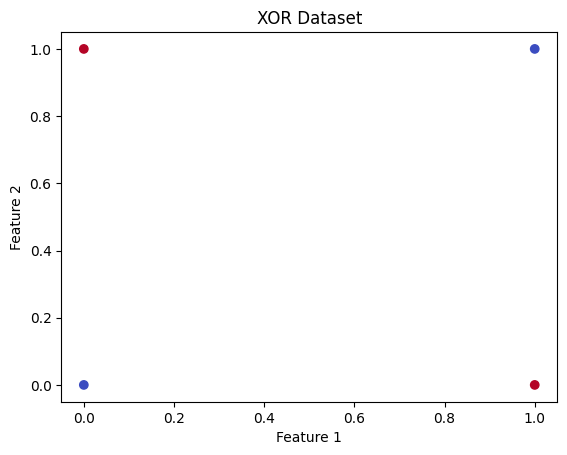

In [3]:
plt.scatter(x[:,0], x[:,1], c=y.flatten(), cmap='coolwarm')
plt.title("XOR Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Initialize MLP Parameter

In [4]:
np.random.seed(42)

input_size = 2
hidden_size = 3
output_size = 1

w1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

w2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

print("w1:\n", w1)
print("w2:\n", w2)

w1:
 [[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]]
w2:
 [[ 1.57921282]
 [ 0.76743473]
 [-0.46947439]]


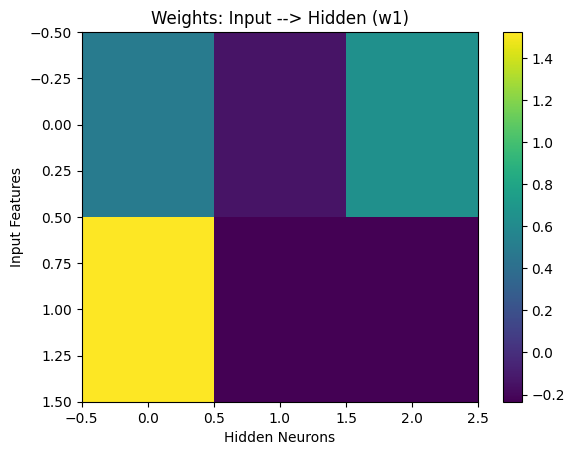

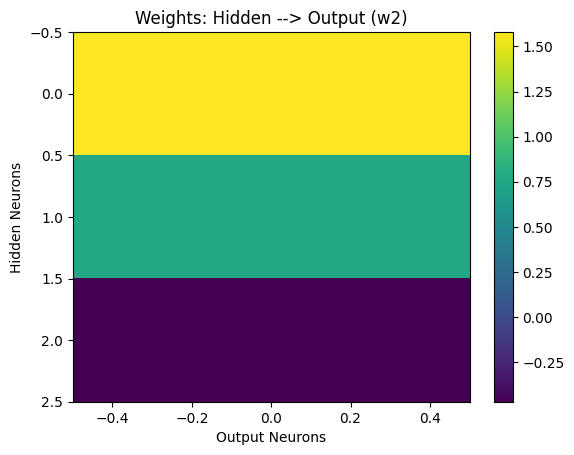

In [6]:
# visualize: Weights as Heatmap
plt.imshow(w1, aspect='auto')
plt.colorbar()
plt.title("Weights: Input --> Hidden (w1)")
plt.xlabel("Hidden Neurons")
plt.ylabel("Input Features")
plt.show()

plt.imshow(w2, aspect='auto')
plt.colorbar()
plt.title("Weights: Hidden --> Output (w2)")
plt.xlabel("Output Neurons")
plt.ylabel("Hidden Neurons")
plt.show()

Activation Function

In [7]:
def sigmoid(x):
  return 1 / (1+ np.exp(-x))

In [8]:
# forward propagation
def forward(x):
  z1 =np.dot(x, w1) + b1
  a1 = sigmoid(z1)

  z2 = np.dot(a1, w2) + b2
  a2 = sigmoid(z2)

  return z1, a1, z2, a2

In [10]:
# run forward pass
z1 , a1, z2, output = forward(x)
print("Hidden Layer Output:\n", a1)
print("Final Output:\n", output)

Hidden Layer Output:
 [[0.5        0.5        0.5       ]
 [0.82098421 0.44172766 0.44173171]
 [0.62168683 0.46548889 0.65648939]
 [0.88285454 0.40795696 0.60193917]]
Final Output:
 [[0.71881406]
 [0.80660888]
 [0.73707158]
 [0.80607425]]


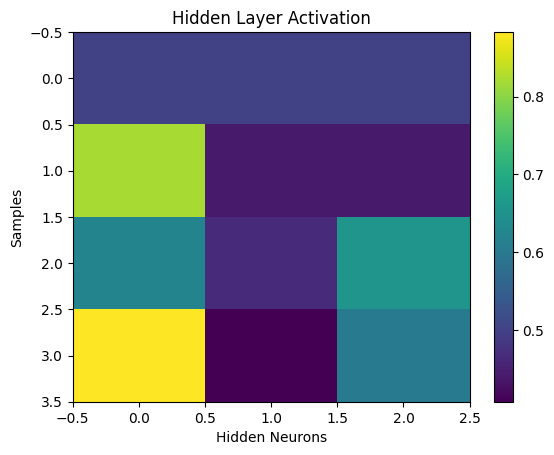

In [12]:
# Visualization: Hidden Layer Activation
plt.imshow(a1, aspect='auto')
plt.colorbar()
plt.title("Hidden Layer Activation")
plt.xlabel("Hidden Neurons")
plt.ylabel("Samples")
plt.show()

Understanding Data Flow

In [13]:
for i in range(len(x)):
  print("\nInput:\n", x[i])
  print(f"Hidden Activations: {a1[i]}")
  print(f"Output :{output[i]}")


Input:
 [0 0]
Hidden Activations: [0.5 0.5 0.5]
Output :[0.71881406]

Input:
 [0 1]
Hidden Activations: [0.82098421 0.44172766 0.44173171]
Output :[0.80660888]

Input:
 [1 0]
Hidden Activations: [0.62168683 0.46548889 0.65648939]
Output :[0.73707158]

Input:
 [1 1]
Hidden Activations: [0.88285454 0.40795696 0.60193917]
Output :[0.80607425]


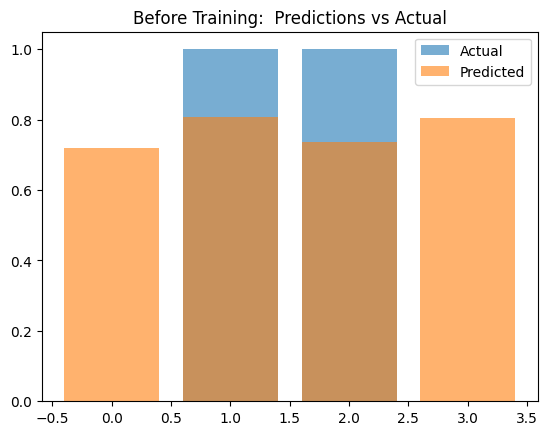

In [14]:
plt.bar(range(len(y)), y.flatten(), alpha=0.6, label='Actual')
plt.bar(range(len(output)), output.flatten(), alpha=0.6, label='Predicted')
plt.legend()
plt.title("Before Training:  Predictions vs Actual")
plt.show()

Error Calcutaion

In [15]:
loss = np.mean((y - output) ** 2)
print("Loss:", loss)

Loss: 0.31824520886068175


In [16]:
#Training with loss Tracking
learning_rate = 0.1
losses = []

for epoch in range(10000):
  z1, a1, z2, output = forward(x)

  loss = np.mean((y - output) ** 2)
  losses.append(loss)

  error = y - output

  d_output = error * output * (1 - output)
  d_hidden = d_output.dot(w2.T) * a1 * (1 - a1)

  w2 += a1.T.dot(d_output) * learning_rate
  w1 += x.T.dot(d_hidden) * learning_rate

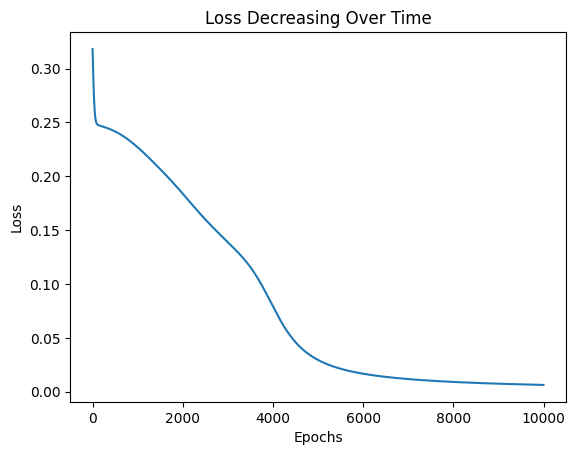

In [17]:
# Visualization: Loss Curve
plt.plot(losses)
plt.title("Loss Decreasing Over Time")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [20]:
_, _, _, predictions = forward(x)
print("Predictions:\n", predictions)

Predictions:
 [[0.10846339]
 [0.92615799]
 [0.92496146]
 [0.05022337]]


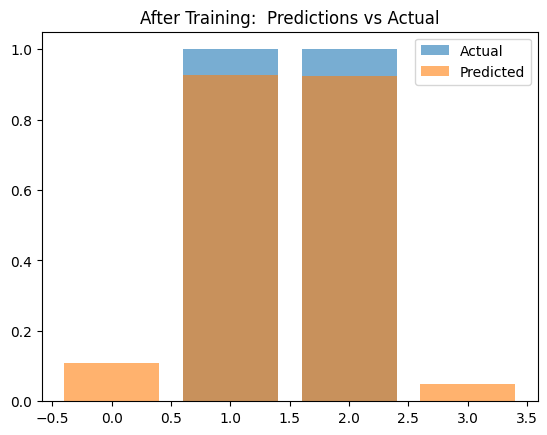

In [22]:
plt.bar(range(len(y)), y.flatten(), alpha=0.6, label='Actual')
plt.bar(range(len(predictions)), predictions.flatten(), alpha=0.6, label='Predicted')
plt.legend()
plt.title("After Training:  Predictions vs Actual")
plt.show()

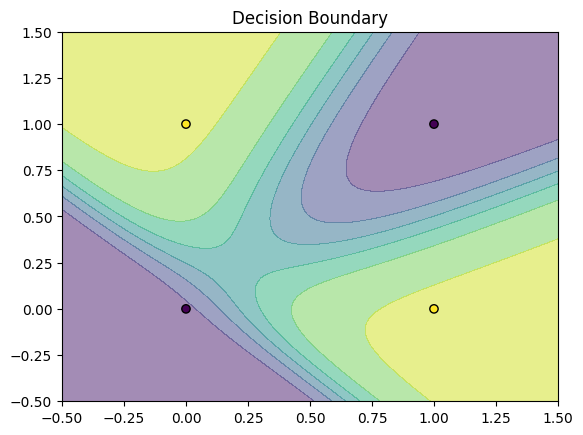

In [23]:
xx, yy  = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))

grid = np.c_[xx.ravel(), yy.ravel()]
_, _, _, preds = forward(grid)

Z =preds.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha= 0.5)
plt.scatter(x[:,0], x[:,1], c=y.flatten(), edgecolors='k')
plt.title("Decision Boundary")
plt.show()